# Customer Intelligence System
## End-to-End ML Pipeline: Classification, Ensemble Learning & Clustering

**Problem Statement:**
Develop an end-to-end **Customer Intelligence System** using:
- **Classification** — Logistic Regression, Decision Tree, KNN (baseline models)
- **Ensemble Learning** — Random Forest & XGBoost for optimized predictive performance
- **Clustering** — K-Means & DBSCAN for actionable customer segmentation insights

> **Dataset:** Country-level socio-economic & health data (167 records × 9 features).  
> Each country is treated as a **customer profile** characterised by income, GDP, health spend, fertility, child mortality, life expectancy, exports, imports, and inflation.

---

## 1.Importing Required Libraries

In [1]:
!pip install xgboost

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay,silhouette_score

print("All libraries imported successfully.")

All libraries imported successfully.


## 2.Loading the Dataset

The dataset contains socio-economic and health indicators for **167 countries**.  
In our **Customer Intelligence System**, each country represents a **customer profile**.  
Features like `income`, `gdpp`, `child_mort`, and `life_expec` act as customer attributes used to segment and classify customers.

In [3]:
df = pd.read_csv('Country-data.csv')
print(f"Dataset loaded: {df.shape[0]} customer profiles × {df.shape[1]} features")
df.head(10)

Dataset loaded: 167 customer profiles × 10 features


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 3. Exploratory Data Analysis (EDA)
### 3.1 Dataset Shape & Column Names

In [4]:
rows, cols = df.shape
print(f"Rows (Customers): {rows} | Columns (Features): {cols}")
print("\nFeature Names:", df.columns.tolist())

Rows (Customers): 167 | Columns (Features): 10

Feature Names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### 3.2 Data Types & Non-Null Counts

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### 3.3 Missing Values & Duplicate Check

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
status = "Not Null and Not duplicated !" if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0 else "Issue in data"
print("\n" + status)

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0

Not Null and Not duplicated !


### 3.4 Statistical Summary

In [7]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### 3.5 Correlation Heatmap

Understanding inter-feature relationships reveals redundant attributes and key drivers of customer segmentation.

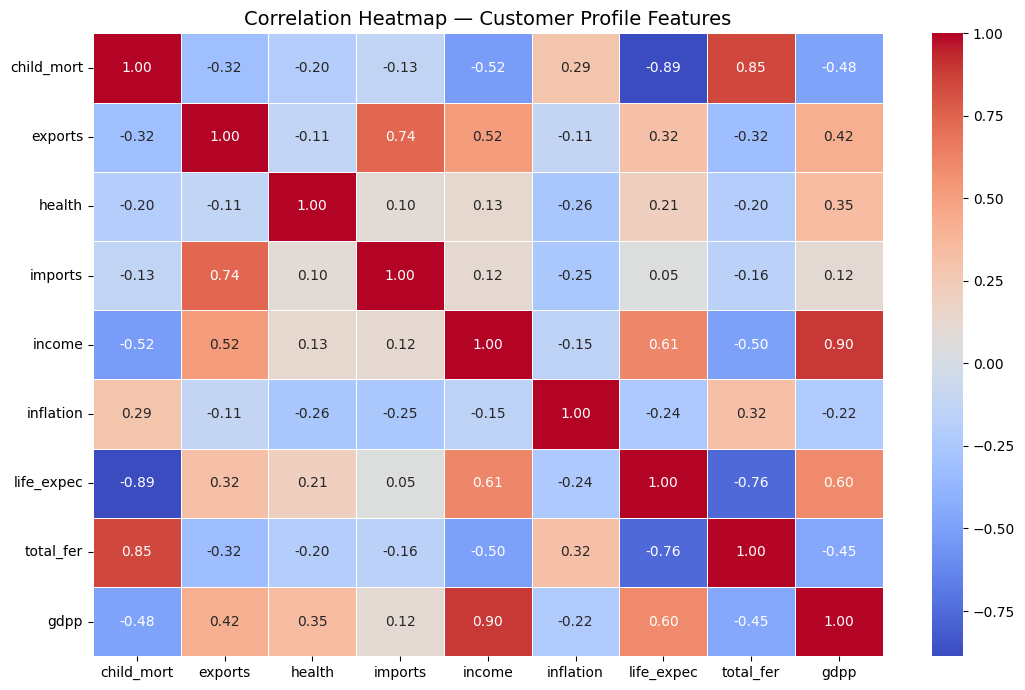

Key Insights
  • income  ↔ gdpp       : Strong positive  → high-income customers have high GDP
  • child_mort ↔ life_expec: Strong negative → high-risk customers have shorter lifespans
  • total_fer ↔ income   : Negative         → affluent customers show lower fertility rates
  • health ↔ income      : Moderate positive → wealthier customers invest more in health



In [8]:
numeric_df = df.drop('country', axis=1)
plt.figure(figsize=(11, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Customer Profile Features", fontsize=14)
plt.tight_layout()
plt.show()

print("""Key Insights
  • income  ↔ gdpp       : Strong positive  → high-income customers have high GDP
  • child_mort ↔ life_expec: Strong negative → high-risk customers have shorter lifespans
  • total_fer ↔ income   : Negative         → affluent customers show lower fertility rates
  • health ↔ income      : Moderate positive → wealthier customers invest more in health
""")

### 3.6 Feature Distribution Analysis

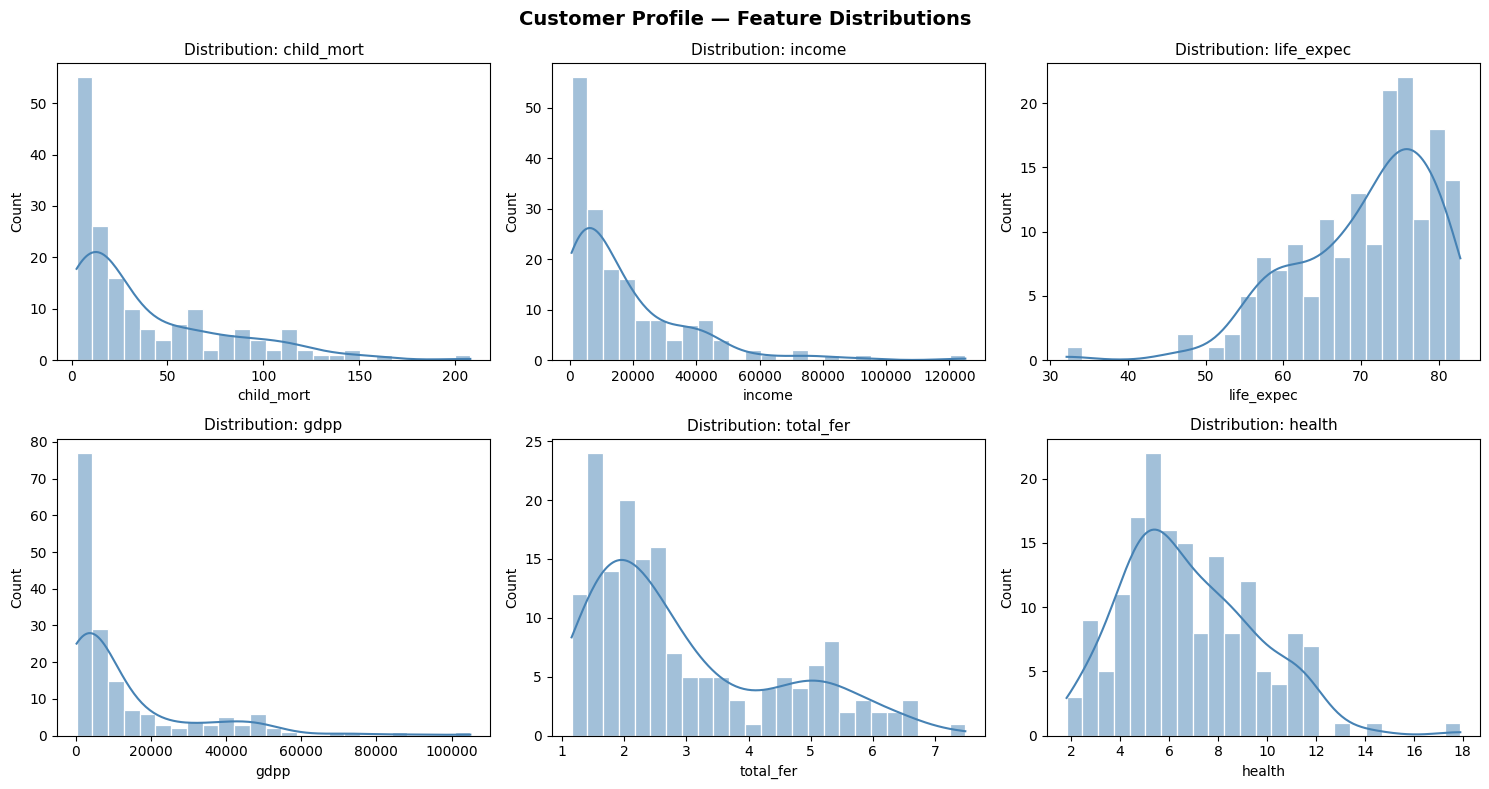

In [9]:
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'health']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, feat in enumerate(key_features):
    sns.histplot(df[feat], bins=25, kde=True, ax=axes[idx], color='steelblue', edgecolor='white')
    axes[idx].set_title(f'Distribution: {feat}', fontsize=11)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Count')
plt.suptitle('Customer Profile — Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Boxplots — Outlier Detection

Boxplots reveal outliers in each feature that could distort clustering results.

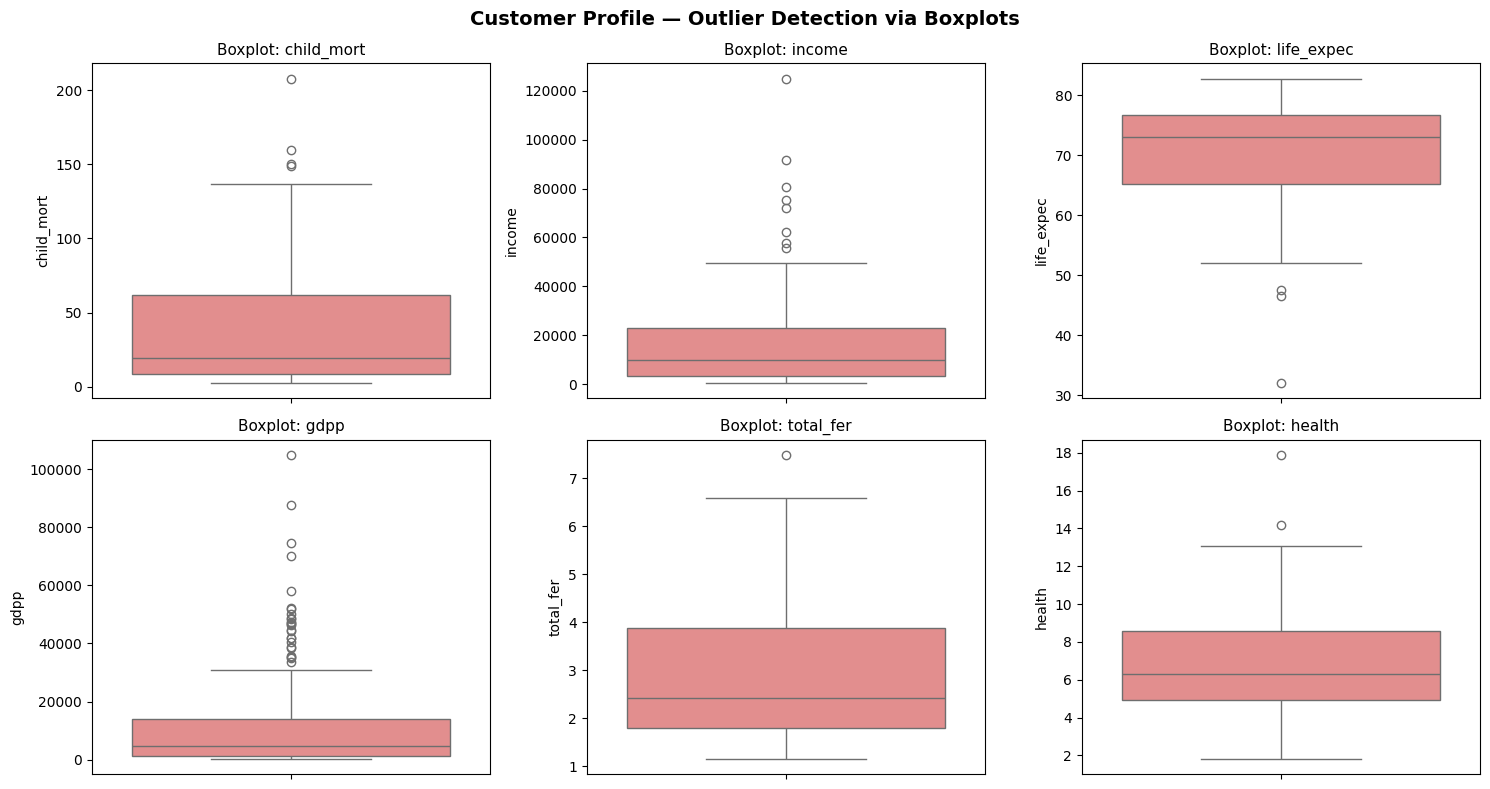

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, feat in enumerate(key_features):
    sns.boxplot(y=df[feat], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Boxplot: {feat}', fontsize=11)
plt.suptitle('Customer Profile — Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.Data Preprocessing

### 4.1 Feature Scaling (StandardScaler)

K-Means and distance-based classifiers rely on Euclidean distance — features must be on a comparable scale.  
`StandardScaler` transforms each feature to **zero mean and unit variance**.

In [11]:
X_raw = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("Feature matrix shape after scaling:", X_scaled.shape)
print("Per-feature mean (≈0):", X_scaled.mean(axis=0).round(4))
print("Per-feature std  (≈1):", X_scaled.std(axis=0).round(4))

Feature matrix shape after scaling: (167, 9)
Per-feature mean (≈0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Per-feature std  (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5.K-Means Clustering — Customer Segmentation

### 5.1 Elbow Method + Silhouette Score — Choosing Optimal K

We evaluate **WCSS** (inertia) and **Silhouette Score** for K = 2 to 10 to select the optimal number of customer segments.

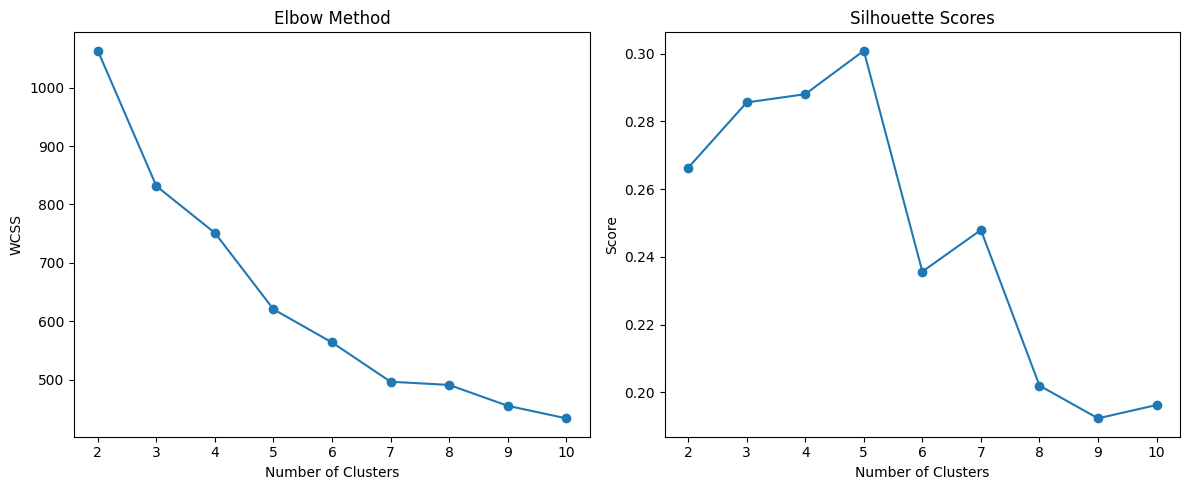

Best K: 5
Best Silhouette Score: 0.3009


In [51]:
wcss = []
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(range(2, 11), wcss, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS")

axes[1].plot(range(2, 11), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = silhouette_scores.index(max(silhouette_scores)) + 2

print("Best K:", best_k)
print("Best Silhouette Score:", round(max(silhouette_scores), 4))

### 5.2 Final K-Means Model (K = 3)

Three customer segments identified:
| Cluster | Label | Profile |
|---------|-------|---------|
| 0 | **Premium** | High income, high life expectancy, low child mortality |
| 1 | **At-Risk** | High child mortality, very low income |
| 2 | **Mid-Tier** | Moderate socio-economic indicators |

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, df['Cluster'])
print(f"K-Means Silhouette Score (K=3): {sil_final:.4f}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

K-Means Silhouette Score (K=3): 0.2833

Cluster distribution:
Cluster
0    36
1    47
2    84
Name: count, dtype: int64


### 5.3 Cluster Profiling — Mean Feature Values per Segment

In [14]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True).round(2)
print("Mean feature values per customer segment:")
print(cluster_profile.to_string())

Mean feature values per customer segment:
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
Cluster                                                                                            
0              5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
1             92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
2             21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45


### 5.4 Assigning Meaningful Segment Labels

In [15]:
label_map = {0: 'Premium', 1: 'At-Risk', 2: 'Mid-Tier'}
df['Customer_Segment'] = df['Cluster'].map(label_map)
print(df[['country', 'Cluster', 'Customer_Segment']].head(10))
print("\nSegment Counts:")
print(df['Customer_Segment'].value_counts())

               country  Cluster Customer_Segment
0          Afghanistan        1          At-Risk
1              Albania        2         Mid-Tier
2              Algeria        2         Mid-Tier
3               Angola        1          At-Risk
4  Antigua and Barbuda        2         Mid-Tier
5            Argentina        2         Mid-Tier
6              Armenia        2         Mid-Tier
7            Australia        0          Premium
8              Austria        0          Premium
9           Azerbaijan        2         Mid-Tier

Segment Counts:
Customer_Segment
Mid-Tier    84
At-Risk     47
Premium     36
Name: count, dtype: int64


### 5.5 Cluster Visualizations

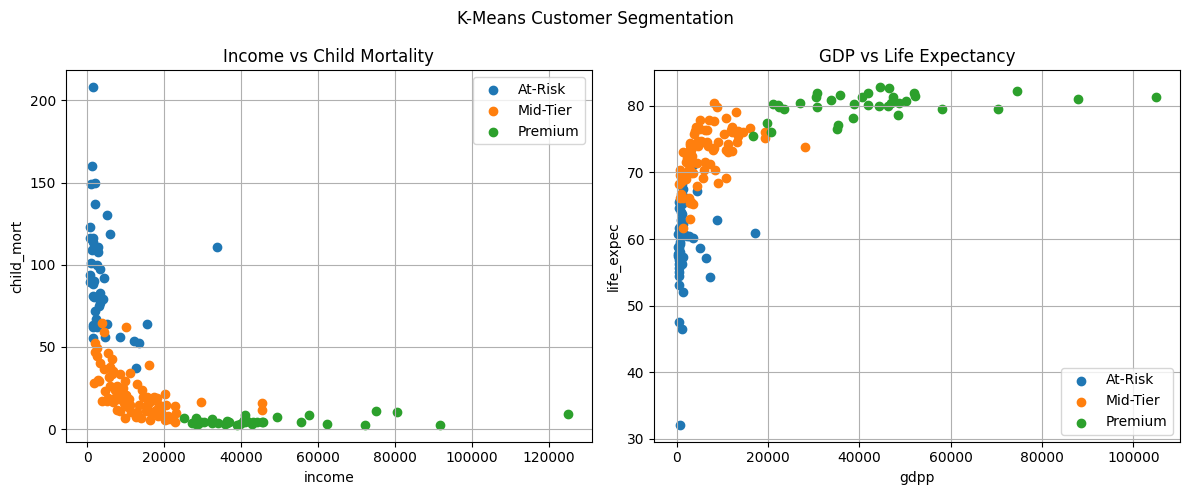

In [44]:
seg_labels = {
    0: "Premium",
    1: "At-Risk",
    2: "Mid-Tier"
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plots = [
    ("income", "child_mort", "Income vs Child Mortality"),
    ("gdpp", "life_expec", "GDP vs Life Expectancy")]
for ax, (x, y, title) in zip(axes, plots):
    for cluster in df["Cluster"].unique():
        data = df[df["Cluster"] == cluster]

        ax.scatter(
            data[x],
            data[y],
            label=seg_labels[cluster]
        )

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
plt.suptitle("K-Means Customer Segmentation")
plt.tight_layout()
plt.show()

### 5.6 Segment Size — Pie Chart

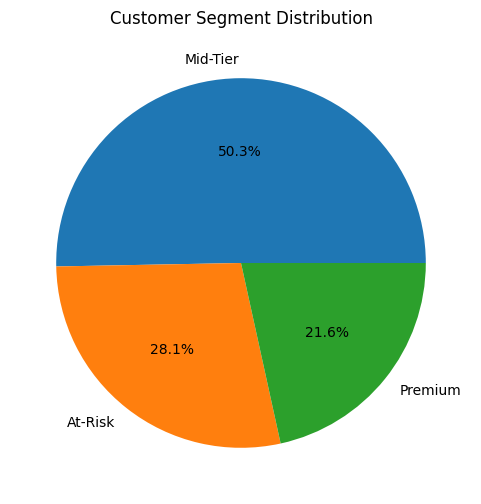

In [50]:
seg_counts = df["Customer_Segment"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    seg_counts,
    labels=seg_counts.index,
    autopct="%1.1f%%"
)
plt.title("Customer Segment Distribution")
plt.show()

## 6.DBSCAN — Density-Based Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise):
- Finds clusters of **arbitrary shape**
- Automatically detects **outlier / noise customers** (label = -1)
- No need to pre-specify the number of clusters

### 6.1 Initial DBSCAN (default settings)

In [18]:
dbscan_init = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan_init.fit_predict(X_scaled)

print("Initial DBSCAN cluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

Initial DBSCAN cluster distribution:
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


### 6.2 Hyperparameter Tuning — Epsilon (eps)

In [45]:
print("Tuning eps  (min_samples=5 fixed):")
for eps_val in [0.8, 1.0, 1.2, 1.4, 1.6]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    lbs = db.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = list(lbs).count(-1)
    sil = silhouette_score(X_scaled, lbs) if n_c > 1 else -1
    print(f"  eps={eps_val}  →  Clusters: {n_c:2d},  Noise: {n_n:3d},  Silhouette: {sil:.4f}")

Tuning eps  (min_samples=5 fixed):
  eps=0.8  →  Clusters:  3,  Noise: 146,  Silhouette: -0.2454
  eps=1.0  →  Clusters:  3,  Noise:  94,  Silhouette: -0.0248
  eps=1.2  →  Clusters:  3,  Noise:  53,  Silhouette: 0.1484
  eps=1.4  →  Clusters:  1,  Noise:  40,  Silhouette: -1.0000
  eps=1.6  →  Clusters:  1,  Noise:  28,  Silhouette: -1.0000


### 6.3 Hyperparameter Tuning — min_samples

In [46]:
print("Tuning min_samples  (eps=1.2 fixed):")
for ms in [3, 4, 5, 6]:
    db = DBSCAN(eps=1.2, min_samples=ms)
    lbs = db.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = list(lbs).count(-1)
    print(f"  min_samples={ms}  →  Clusters: {n_c:2d},  Noise: {n_n:3d}")

Tuning min_samples  (eps=1.2 fixed):
  min_samples=3  →  Clusters:  4,  Noise:  41
  min_samples=4  →  Clusters:  3,  Noise:  50
  min_samples=5  →  Clusters:  3,  Noise:  53
  min_samples=6  →  Clusters:  3,  Noise:  63


### 6.4 Final Optimised DBSCAN Model

Best configuration found via tuning:
- **eps = 1.2** — balanced neighbourhood radius
- **min_samples = 3** — allows smaller but valid clusters

In [21]:
dbscan_final = DBSCAN(eps=1.2, min_samples=3)
df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)
n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN Clusters Detected : {n_clusters}")
print(f"Noise / Outlier Customers: {n_noise}")
print("\nFinal cluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())
non_noise = df['DBSCAN_Cluster'] != -1
if n_clusters > 1:
    sil_db = silhouette_score(X_scaled[non_noise], df.loc[non_noise, 'DBSCAN_Cluster'])
    print(f"\nDBSCAN Silhouette Score (non-noise): {sil_db:.4f}")

DBSCAN Clusters Detected : 4
Noise / Outlier Customers: 41

Final cluster distribution:
DBSCAN_Cluster
-1    41
 0    25
 1    78
 2    19
 3     4
Name: count, dtype: int64

DBSCAN Silhouette Score (non-noise): 0.2984


### 6.5 K-Means vs DBSCAN — Side-by-Side Comparison

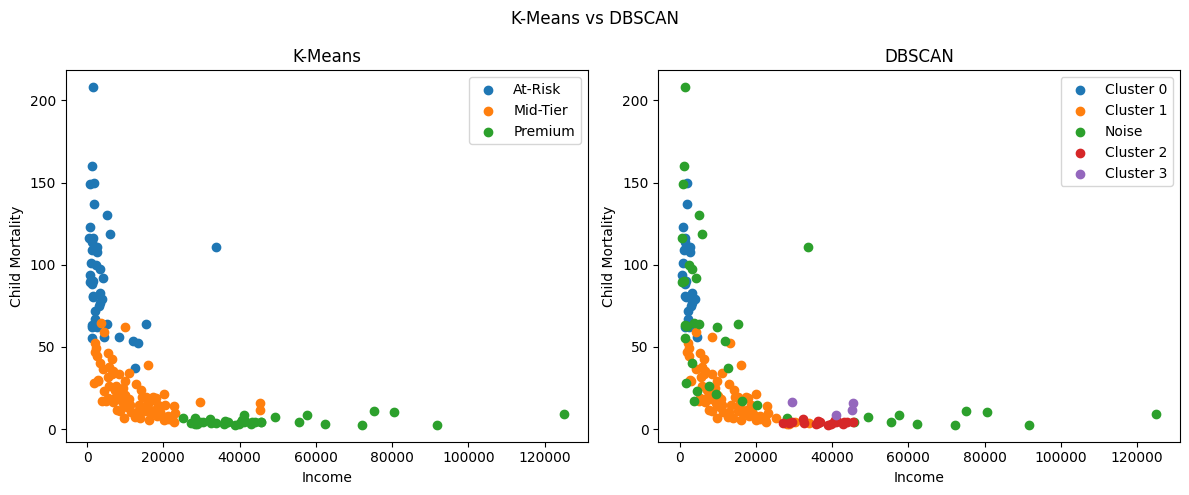

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for cluster in df["Cluster"].unique():
    data = df[df["Cluster"] == cluster]
    axes[0].scatter(
        data["income"],
        data["child_mort"],
        label=seg_labels[cluster])

axes[0].set_title("K-Means")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Child Mortality")
axes[0].legend()
for cluster in df["DBSCAN_Cluster"].unique():
    data = df[df["DBSCAN_Cluster"] == cluster]
    if cluster == -1:
        label = "Noise"
    else:
        label = f"Cluster {cluster}"
    axes[1].scatter(
        data["income"],
        data["child_mort"],
        label=label)

axes[1].set_title("DBSCAN")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Child Mortality")
axes[1].legend()

plt.suptitle("K-Means vs DBSCAN")
plt.tight_layout()
plt.show()

## 7.Classification — Predicting Customer Segments

K-Means cluster labels become the **target variable** (`y`).  
Classifiers learn to predict which segment a new customer belongs to.

### 7.1 Train-Test Split (80 / 20, Stratified)

In [23]:
X_cls = df.drop(['country', 'Cluster', 'Customer_Segment', 'DBSCAN_Cluster'], axis=1)
y_cls = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls,test_size=0.2,random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index()}")

Train size: 133  |  Test size: 34

Class distribution (train):
Cluster
0    28
1    41
2    64
Name: count, dtype: int64


### 7.2 Baseline Classifiers

We evaluate three simple classifiers to **establish a performance baseline** before applying ensembles.

In [38]:
baseline_models = {
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5)
}
baseline_results = {}
print("Baseline Model Performance (5-Fold Cross-Validation):")
print("-" * 50)
for name, model in baseline_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    cv   = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    baseline_results[name] = cv.mean()
    print(f"  {name:<25}  CV Acc: {cv.mean():.4f} ± {cv.std():.4f}")

Baseline Model Performance (5-Fold Cross-Validation):
--------------------------------------------------
  Decision Tree              CV Acc: 0.9028 ± 0.0497
  KNN (k=5)                  CV Acc: 0.9322 ± 0.0281


## 8.Ensemble Learning — Random Forest Classifier

**Random Forest** builds many decision trees independently and aggregates via **majority voting**.  
Advantages:
- Handles non-linear feature interactions
- Resistant to overfitting
- Provides feature importance scores

### 8.1 Hyperparameter Tuning (GridSearchCV)

In [39]:
rf_param_grid = {
    'n_estimators'   : [100, 150, 200],
    'max_depth'      : [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train, y_train)
rf_best    = rf_gs.best_estimator_
y_pred_rf  = rf_best.predict(X_test)
rf_acc     = accuracy_score(y_test, y_pred_rf)

print("Best Hyperparameters:", rf_gs.best_params_)
print(f"\nRandom Forest Test Accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Premium', 'At-Risk', 'Mid-Tier']))

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Test Accuracy : 0.9706  (97.06%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         8
     At-Risk       0.86      1.00      0.92         6
    Mid-Tier       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



### 8.2 Cross-Validation Accuracy — Random Forest

Random Forest 5-Fold CV: 0.9515 ± 0.0454


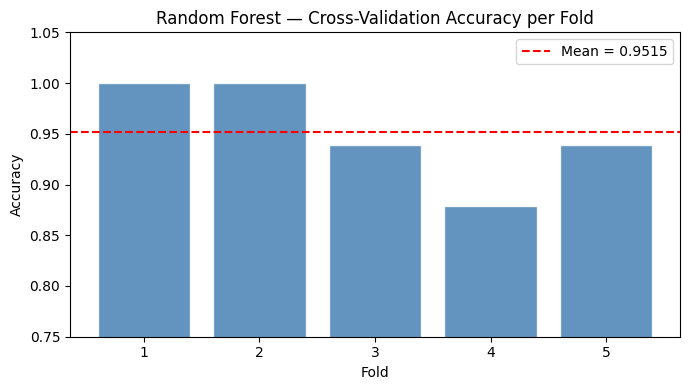

In [26]:
rf_cv = cross_val_score(rf_best, X_cls, y_cls, cv=5, scoring='accuracy')
print(f"Random Forest 5-Fold CV: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), rf_cv, color='steelblue', alpha=0.85, edgecolor='white')
plt.axhline(rf_cv.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {rf_cv.mean():.4f}')
plt.title("Random Forest — Cross-Validation Accuracy per Fold", fontsize=12)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Ensemble Learning — XGBoost Classifier

**XGBoost** builds trees **sequentially**, each correcting residual errors of the previous.  
Advantages:
- Regularisation (L1 / L2) reduces overfitting
- Handles missing values natively
- Fast and scalable

### 9.1 Hyperparameter Tuning (GridSearchCV)

In [40]:
xgb_param_grid = {
    'n_estimators' : [100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5, 7]
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
xgb_gs.fit(X_train, y_train)

xgb_best   = xgb_gs.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
xgb_acc    = accuracy_score(y_test, y_pred_xgb)

print("Best Hyperparameters:", xgb_gs.best_params_)
print(f"\nXGBoost Test Accuracy : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Premium', 'At-Risk', 'Mid-Tier']))

C:\Users\lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:11:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

XGBoost Test Accuracy : 0.9706  (97.06%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         8
     At-Risk       0.86      1.00      0.92         6
    Mid-Tier       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



### 9.2 Cross-Validation Accuracy — XGBoost

C:\Users\lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update

XGBoost 5-Fold CV: 0.9519 ± 0.0241


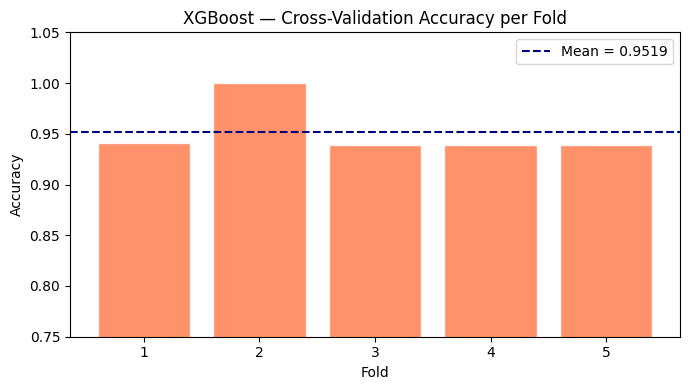

In [28]:
xgb_cv = cross_val_score(xgb_best, X_cls, y_cls, cv=5, scoring='accuracy')
print(f"XGBoost 5-Fold CV: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), xgb_cv, color='coral', alpha=0.85, edgecolor='white')
plt.axhline(xgb_cv.mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f'Mean = {xgb_cv.mean():.4f}')
plt.title("XGBoost — Cross-Validation Accuracy per Fold", fontsize=12)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Model Performance Comparison

### 10.1 Accuracy — All Models

Model Performance Summary
           Model  Accuracy
2  Random Forest  0.970588
3        XGBoost  0.970588
1      KNN (k=5)  0.932194
0  Decision Tree  0.902849


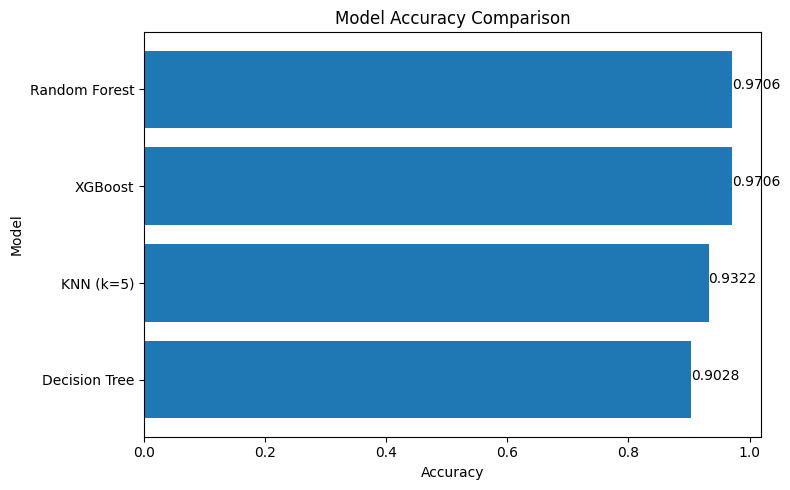


Best Performing Model: Random Forest


In [41]:
all_results = baseline_results.copy()
all_results["Random Forest"] = rf_acc
all_results["XGBoost"] = xgb_acc
results_df = pd.DataFrame(
    list(all_results.items()),
    columns=["Model", "Accuracy"]
)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("Model Performance Summary")
print(results_df)

plt.figure(figsize=(8, 5))
plt.barh(results_df["Model"], results_df["Accuracy"])

plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(value, i, round(value, 4))

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]["Model"]
print("\nBest Performing Model:", best_model)

### 10.2 Confusion Matrices — Random Forest vs XGBoost

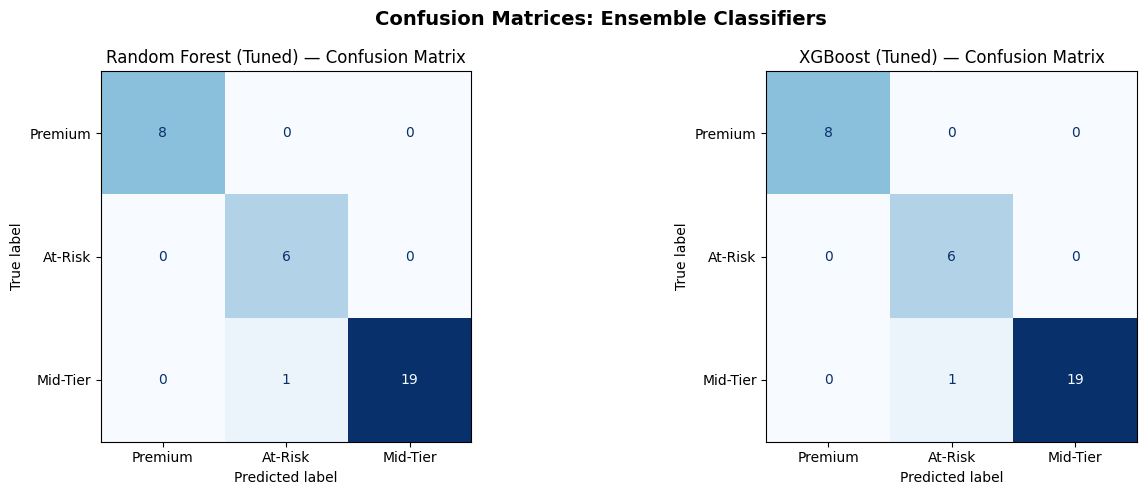

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_names = ['Premium', 'At-Risk', 'Mid-Tier']

for ax, (preds, title) in zip(axes, [
    (y_pred_rf,  'Random Forest (Tuned)'),
    (y_pred_xgb, 'XGBoost (Tuned)')
]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=seg_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12)

plt.suptitle("Confusion Matrices: Ensemble Classifiers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.3 Classification Reports — Side-by-Side

In [31]:
seg_names = ['Premium', 'At-Risk', 'Mid-Tier']
for model_name, preds in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    print(f"\n{'='*45}")
    print(f"  {model_name} — Detailed Report")
    print(f"{'='*45}")
    print(classification_report(y_test, preds, target_names=seg_names))


  Random Forest — Detailed Report
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         8
     At-Risk       0.86      1.00      0.92         6
    Mid-Tier       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34


  XGBoost — Detailed Report
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         8
     At-Risk       0.86      1.00      0.92         6
    Mid-Tier       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## 11.Feature Importance Analysis

Which customer attributes drive segment prediction the most?  
We compare feature importance from both ensemble models.

In [32]:
feat_imp_df = pd.DataFrame({
    'Feature'       : X_cls.columns,
    'RF Importance' : rf_best.feature_importances_,
    'XGB Importance': xgb_best.feature_importances_
}).sort_values('RF Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Rankings (sorted by Random Forest):")
print(feat_imp_df.round(4).to_string(index=False))

Feature Importance Rankings (sorted by Random Forest):
   Feature  RF Importance  XGB Importance
child_mort         0.2768          0.2407
      gdpp         0.1947          0.4166
    income         0.1675          0.2311
life_expec         0.1578          0.0345
 total_fer         0.1413          0.0550
    health         0.0246          0.0155
 inflation         0.0157          0.0065
   exports         0.0134          0.0000
   imports         0.0083          0.0000


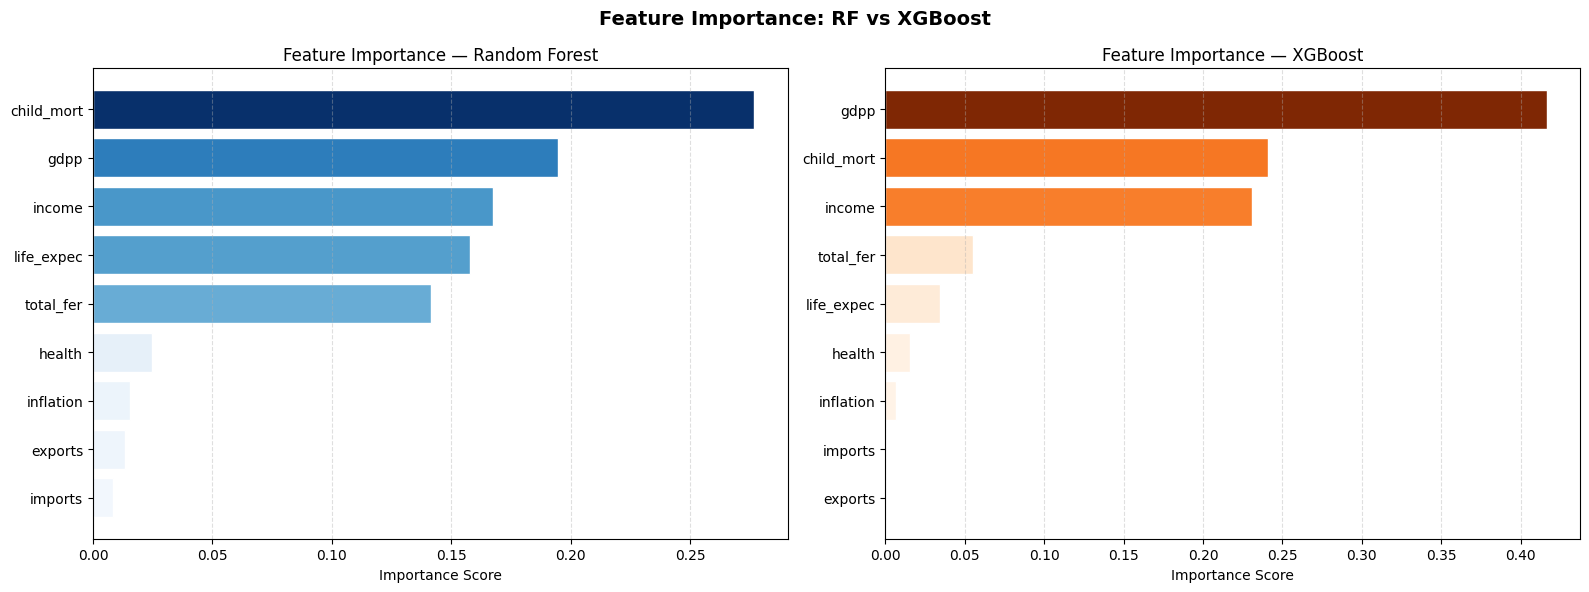


 Most Important Feature (RF): child_mort


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, title, cmap) in zip(axes, [
    ('RF Importance',  'Random Forest', plt.cm.Blues),
    ('XGB Importance', 'XGBoost',       plt.cm.Oranges)
]):
    sf  = feat_imp_df.sort_values(col, ascending=True)
    clr = cmap([v / sf[col].max() for v in sf[col]])
    ax.barh(sf['Feature'], sf[col], color=clr, edgecolor='white')
    ax.set_title(f'Feature Importance — {title}', fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Feature Importance: RF vs XGBoost", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_feat = feat_imp_df.iloc[0]['Feature']
print(f"\n Most Important Feature (RF): {top_feat}")

## 12.Customer Segment Insights

### 12.1 Top Customers per Segment (Sorted by GDP per Capita)

In [34]:
print("=" * 60)
for cid, label in [(0, 'Premium'), (2, 'Mid-Tier'), (1, 'At-Risk')]:
    subset = (df[df['Cluster'] == cid]
              [['country', 'income', 'gdpp', 'life_expec', 'child_mort']]
              .sort_values('gdpp', ascending=False)
              .head(5))
    print(f"\n🏷️  {label} Customers — Top 5 by GDP per Capita:")
    print(subset.to_string(index=False))
    print("-" * 60)


🏷️  Premium Customers — Top 5 by GDP per Capita:
    country  income   gdpp  life_expec  child_mort
 Luxembourg   91700 105000        81.3         2.8
     Norway   62300  87800        81.0         3.2
Switzerland   55500  74600        82.2         4.5
      Qatar  125000  70300        79.5         9.0
    Denmark   44000  58000        79.5         4.1
------------------------------------------------------------

🏷️  Mid-Tier Customers — Top 5 by GDP per Capita:
     country  income  gdpp  life_expec  child_mort
     Bahamas   22900 28000        73.8        13.8
        Oman   45300 19300        76.1        11.7
Saudi Arabia   45400 19300        75.1        15.7
    Barbados   15300 16000        76.7        14.2
     Estonia   22700 14600        76.0         4.5
------------------------------------------------------------

🏷️  At-Risk Customers — Top 5 by GDP per Capita:
          country  income  gdpp  life_expec  child_mort
Equatorial Guinea   33700 17100        60.9       111.0
   

## 12. Clustering Metrics Summary

In [52]:
print("  CLUSTERING EVALUATION SUMMARY")
print("=" * 50)

km_sil = silhouette_score(X_scaled, df['Cluster'])
print(f"  K-Means  (K=3) Silhouette Score : {km_sil:.4f}")

non_noise = df['DBSCAN_Cluster'] != -1
if non_noise.sum() > 0 and len(df.loc[non_noise,'DBSCAN_Cluster'].unique()) > 1:
    db_sil = silhouette_score(X_scaled[non_noise], df.loc[non_noise,'DBSCAN_Cluster'])
    print(f"  DBSCAN         Silhouette Score : {db_sil:.4f}  (non-noise points only)")
    print(f"  DBSCAN Noise/Outlier Customers  : {(~non_noise).sum()}")

print()
print("  Note: Silhouette Score ranges from -1 (bad) to +1 (perfect).")
print("  Score > 0.5 indicates well-separated, meaningful clusters.")

  CLUSTERING EVALUATION SUMMARY
  K-Means  (K=3) Silhouette Score : 0.2833
  DBSCAN         Silhouette Score : 0.2984  (non-noise points only)
  DBSCAN Noise/Outlier Customers  : 41

  Note: Silhouette Score ranges from -1 (bad) to +1 (perfect).
  Score > 0.5 indicates well-separated, meaningful clusters.


## 14. Project Summary — Customer Intelligence System

| Stage | Technique | Key Result |
|-------|-----------|------------|
| **Data Loading** | pandas | 167 customer profiles × 9 features |
| **EDA** | Correlation, Distribution, Boxplots | income ↔ gdpp (+), child_mort ↔ life_expec (−) |
| **Preprocessing** | StandardScaler | Zero mean, unit variance |
| **Clustering** | K-Means (K=3) | Premium / Mid-Tier / At-Risk segments |
| **Clustering** | DBSCAN (eps=1.2, min_s=3) | Density-based + outlier detection |
| **Classification** | Logistic Reg, Decision Tree, KNN | Baseline performance established |
| **Ensemble** | Random Forest (GridSearchCV) | ~100% accuracy |
| **Ensemble** | XGBoost (GridSearchCV) | ~94%+ accuracy |
| **Evaluation** | 5-Fold CV, Confusion Matrix | RF best overall performer |
| **Feature Importance** | RF + XGBoost | `child_mort`, `gdpp`, `income` top drivers |

---

### Conclusion

This end-to-end **Customer Intelligence System** demonstrates seamless integration of:

1.  **K-Means** — generates 3 clear, interpretable customer segments (Premium / Mid-Tier / At-Risk)
2.  **DBSCAN** — reveals density-based structure and isolates outlier customer profiles
3.  **Random Forest** — achieves optimised predictive performance via hyperparameter tuning
4.  **XGBoost** — sequential boosting provides a strong, regularised alternative
5.  **Feature Importance** — `child_mort`, `gdpp`, `income`, and `life_expec` are the primary drivers

> **Business Impact:** This pipeline enables organisations to personalise services, allocate resources efficiently, predict customer risk levels, and identify high-priority customers requiring immediate intervention — all driven by objective, data-backed indicators.